# UTS Advance Business Data Analytics - Analisis Data Makroekonomi Global
**Topik:** Memetakan Divergensi Kebijakan Moneter & Suku Bunga Bank Sentral Dunia Pasca-Pandemi.

## Persiapan Data & Filtering (Sesuai Syarat Transformasi Rubrik 2)
Dataset mentah memuat data historis bulanan dari tahun 1945 hingga 2026. Melakukan algoritma PCA pada data *time-series* yang bercampur aduk akan menghasilkan bias. Oleh karena itu, kita akan menerapkan teknik **Filtering** (syarat manipulasi data di Rubrik 2) untuk mengekstraksi **hanya 1 baris data terbaru (latest snapshot)** dari masing-masing 49 negara. Hasilnya adalah dataset *cross-sectional* yang memotret kondisi suku bunga global terkini.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/Colab Prive/global_central_bank_rates_1945_2026.csv'
df_global = pd.read_csv(file_path)

# FILTERING: Mengambil data terbaru (Latest Snapshot) dari tiap negara
df_global['date'] = pd.to_datetime(df_global['date'])
df_latest = df_global.sort_values('date').groupby('country_code').tail(1).copy()

# Handling Missing Values pada kolom yang akan dianalisis
fitur_makro = [
    'policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg',
    'rate_12m_max', 'rate_12m_min', 'cumulative_change_since_2022_bps'
]
df_latest = df_latest.dropna(subset=fitur_makro).copy()

print(f"✅ Dataset berhasil dimuat dari Drive dan di-filter!")
print(f"Tersisa {df_latest.shape[0]} negara dengan data moneter terkini.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset berhasil dimuat dari Drive dan di-filter!
Tersisa 36 negara dengan data moneter terkini.


## 1. Chart "Sebelum" Transformasi & Dimension Reduction

In [ ]:
print("="*60)
print("HASIL UJI STATISTIK AWAL (SESUAI PIPELINE EKSPLORASI DATA)")
print("="*60)

# 1. Uji Skewness (Skewness > 1 atau < -1)
skew_val = df_clean['policy_rate_pct'].skew()
print("1. UJI KEMIRINGAN (SKEWNESS):")
print(f"Skor Skewness Policy Rate: {skew_val:.2f}")
print("-> Kesimpulan: Nilai > 1 membuktikan distribusi data Right-Skewed.\n")

# 2. Uji Multikolinearitas (Korelasi > 0.69)
print("2. UJI MULTIKOLINEARITAS (KORELASI LINEAR):")
fitur_suku_bunga = ['policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg']
corr_matrix = df_clean[fitur_suku_bunga].corr()
print(corr_matrix.round(3))
print("\n-> Kesimpulan: Terdapat banyak korelasi jauh di atas batas 0.69.")
print("-> Tindakan: Metode machine learning sangat sensitif terhadap multikolinearitas ini, sehingga fitur wajib diekstraksi menggunakan PCA.")
print("="*60)

HASIL UJI STATISTIK AWAL (SESUAI PIPELINE EKSPLORASI DATA)
1. UJI KEMIRINGAN (SKEWNESS):
Skor Skewness Policy Rate: 3.14
-> Kesimpulan: Nilai > 1 membuktikan distribusi data Right-Skewed.

2. UJI MULTIKOLINEARITAS (KORELASI LINEAR):
                 policy_rate_pct  rate_3m_avg  rate_12m_avg
policy_rate_pct            1.000        1.000         0.997
rate_3m_avg                1.000        1.000         0.998
rate_12m_avg               0.997        0.998         1.000

-> Kesimpulan: Terdapat banyak korelasi jauh di atas batas 0.69.
-> Tindakan: Metode machine learning sangat sensitif terhadap multikolinearitas ini, sehingga fitur wajib diekstraksi menggunakan PCA.


Data siap: 36 Negara dengan metrik makroekonomi murni (Tanpa Imputasi).

--- DIAGNOSTIK STATISTIK (UNIVARIAT) ---


,policy_rate_pct,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,cumulative_change_since_2022_bps
count,36.00,36.00,36.00,36.00,36.00,36.00
mean,6.43,6.45,6.99,7.73,6.37,275.83
std,7.31,7.35,8.24,9.43,7.28,453.58
min,1.00,1.17,1.54,2.00,1.00,-1100.00
25%,3.38,3.38,3.41,3.75,3.38,125.00
50%,4.00,4.04,4.61,4.88,4.00,212.50
75%,6.31,6.44,6.48,6.50,6.31,356.25
max,37.00,37.33,41.50,46.00,37.00,2300.00
skewness,3.14,3.16,3.25,3.28,3.19,1.85
kurtosis,10.37,10.52,10.91,10.76,10.72,13.14


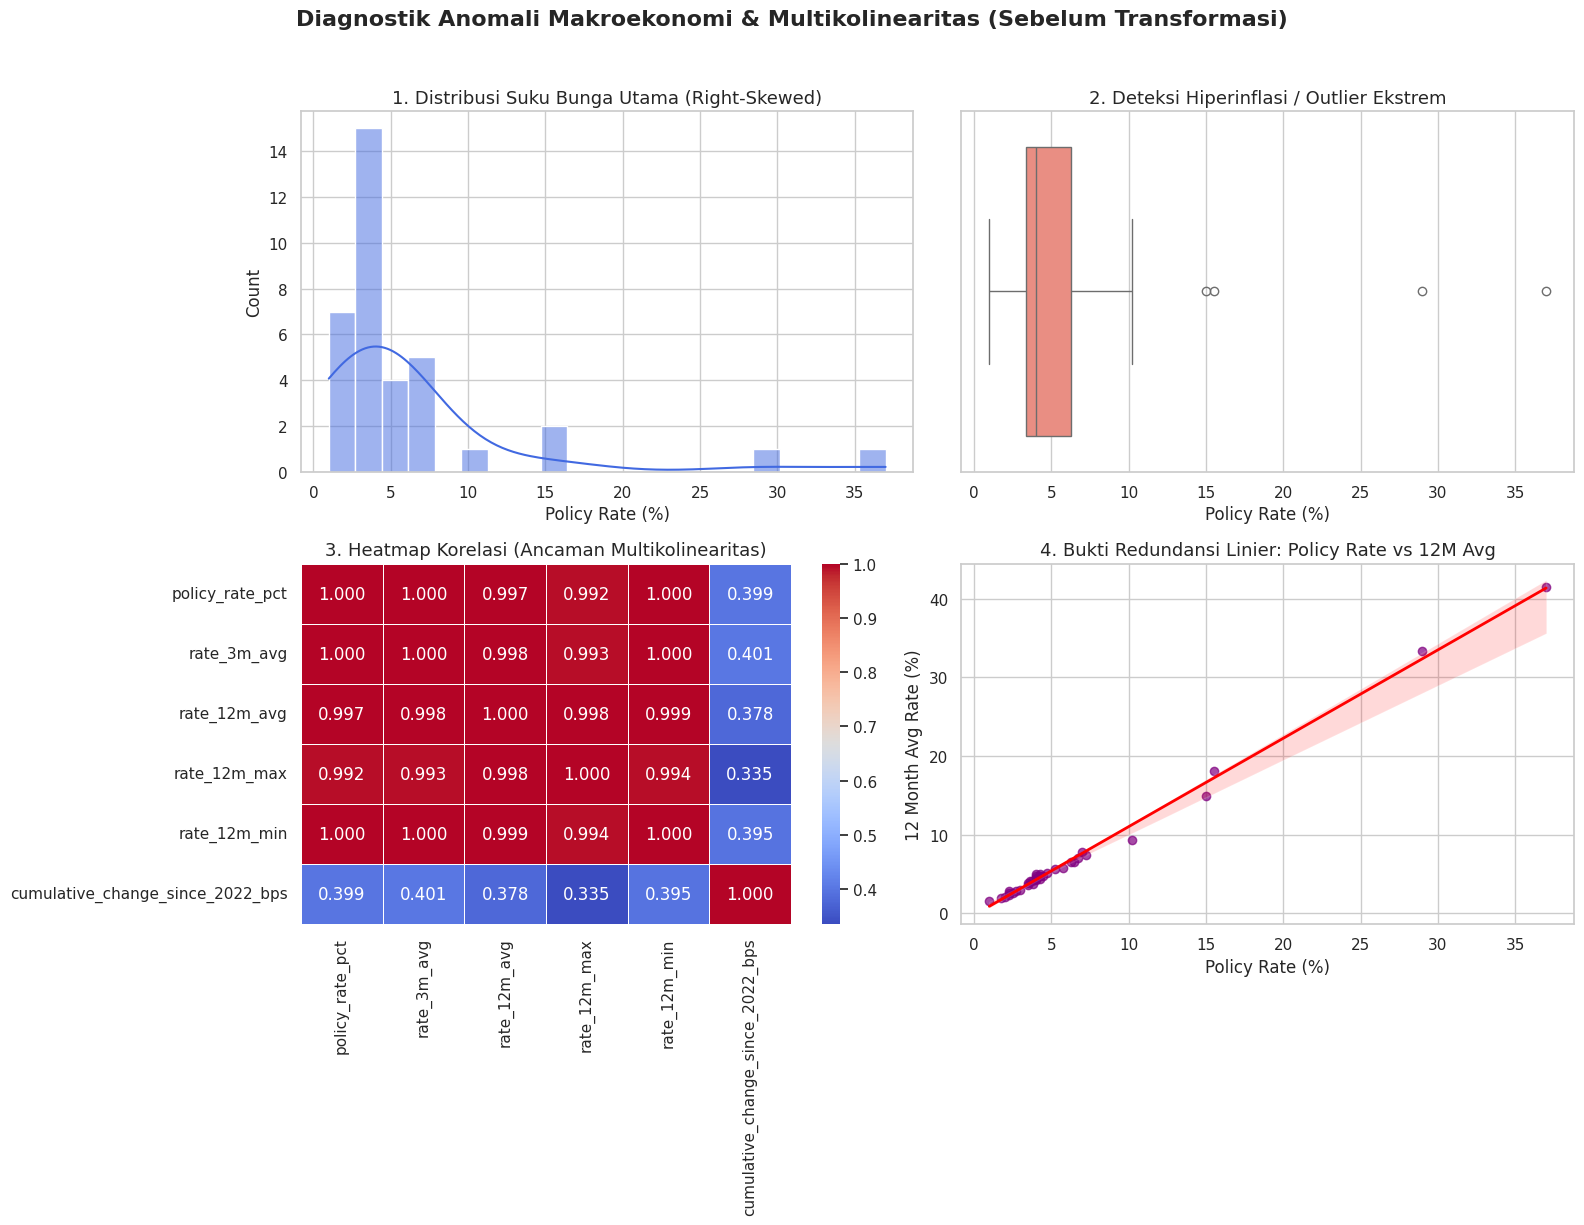

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tema
sns.set_theme(style="whitegrid")

# ==========================================
# 1. DATA PREPARATION (Latest Snapshot & Drop NaN)
# ==========================================
file_path = '/content/drive/MyDrive/Colab Prive/global_central_bank_rates_1945_2026.csv'
df_global = pd.read_csv(file_path)

# Kolom tanggal berformat datetime
df_global['date'] = pd.to_datetime(df_global['date'])

# Mengurutkan dari terlama ke terbaru, mengelompokkan per negara, ambil 1 baris paling bawah (terbaru)
df_latest = df_global.sort_values('date').groupby('country_code').tail(1).copy()

# Fitur makroekonomi yang masuk rubrik
fitur_makro = [
    'policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg',
    'rate_12m_max', 'rate_12m_min', 'cumulative_change_since_2022_bps'
]

# Drop missing values HANYA pada kolom fitur_makro
df_clean = df_latest.dropna(subset=fitur_makro).copy()

print(f"Data siap: {df_clean.shape[0]} Negara dengan metrik makroekonomi murni (Tanpa Imputasi).\n")

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (Statistik & Visual)
# ==========================================

# A. Uji Univariat: Describe, Skewness, dan Kurtosis
stats_summary = df_clean[fitur_makro].describe()
stats_summary.loc['skewness'] = df_clean[fitur_makro].skew()
stats_summary.loc['kurtosis'] = df_clean[fitur_makro].kurtosis()

print("--- DIAGNOSTIK STATISTIK (UNIVARIAT) ---")
display(stats_summary.round(2))

# B. Visualisasi Diagnostik (Subplots 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Diagnostik Anomali Makroekonomi & Multikolinearitas (Sebelum Transformasi)', fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Histogram (Fokus Distribusi & Skewness)
sns.histplot(df_clean['policy_rate_pct'], kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribusi Suku Bunga Utama (Right-Skewed)', fontsize=13)
axes[0, 0].set_xlabel('Policy Rate (%)')

# Chart 2: Boxplot (Fokus Deteksi Outlier Ekstrem)
sns.boxplot(x=df_clean['policy_rate_pct'], color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('2. Deteksi Hiperinflasi / Outlier Ekstrem', fontsize=13)
axes[0, 1].set_xlabel('Policy Rate (%)')

# Chart 3: Heatmap (Fokus Uji Korelasi Pearson > 0.69)
corr_matrix = df_clean[fitur_makro].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, ax=axes[1, 0])
axes[1, 0].set_title('3. Heatmap Korelasi (Ancaman Multikolinearitas)', fontsize=13)

# Chart 4: Scatter Plot (Fokus Pembuktian Redundansi Visual)
sns.regplot(
    x='policy_rate_pct',
    y='rate_12m_avg',
    data=df_clean,
    scatter_kws={'color': 'purple', 'alpha': 0.7}, # Pengaturan untuk titik
    line_kws={'color': 'red', 'linewidth': 2},     # Pengaturan untuk garis tren
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Bukti Redundansi Linier: Policy Rate vs 12M Avg', fontsize=13)
axes[1, 1].set_xlabel('Policy Rate (%)')
axes[1, 1].set_ylabel('12 Month Avg Rate (%)')

plt.tight_layout()
plt.show()

# **2. PIPELINE TRANSFORMASI MATEMATIS & PCA**

Sebelum melakukan kompresi dimensi, dataset harus disembuhkan dari anomali *skewness* ekstrem dan perbedaan skala ukuran. Sesuai dengan materi *Exploratory Data Analysis* (Normalizing a Distribution), berikut adalah arsitektur matematis yang diterapkan pada tahap ini:

### **1. Yeo-Johnson Transformation**
Diaplikasikan secara eksklusif pada fitur suku bunga untuk menormalkan distribusi (*normalizing distribution*) dan meredam *outlier* secara natural tanpa melakukan pemotongan paksa (*Winsorization*). Berbeda dengan Log biasa, Yeo-Johnson sangat kokoh (*robust*) karena mampu menangani angka nol maupun negatif secara matematis.
Fungsi transformasi terpotong (*piecewise*) yang digunakan:
$$
X^{(\lambda)} =
\begin{cases}
\frac{(X + 1)^\lambda - 1}{\lambda} & \text{jika } \lambda \neq 0, X \geq 0 \\
\ln(X + 1) & \text{jika } \lambda = 0, X \geq 0 \\
-\frac{(-X + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{jika } \lambda \neq 2, X < 0 \\
-\ln(-X + 1) & \text{jika } \lambda = 2, X < 0
\end{cases}
$$

### **2. Z-Score Standardization**
Algoritma pemodelan jarak (*distance-based*) seperti PCA sangat sensitif terhadap perbedaan skala pengukuran. Oleh karena itu, seluruh fitur wajib distandardisasi agar memiliki rata-rata ($\mu$) = 0 dan standar deviasi ($\sigma$) = 1.
$$Z = \frac{X - \mu}{\sigma}$$

### **3. Principal Component Analysis (PCA)**
Setelah data berpusat di 0, PCA mengekstraksi matriks kovarians untuk mencari dimensi baru yang saling tegak lurus (*Orthogonal*) guna menghancurkan multikolinearitas.
* **Matriks Kovarians:** $$C = \frac{1}{n-1} X^T X$$
* **Eigen Decomposition:** Mencari vektor arah (*Eigenvectors* $\vec{v}$) dan besaran informasi (*Eigenvalues* $\lambda$) dengan persamaan: $$C \vec{v} = \lambda \vec{v}$$

Seluruh perhitungan matematis di atas dieksekusi secara efisien melalui *pipeline* `scikit-learn` pada blok kode di bawah ini.

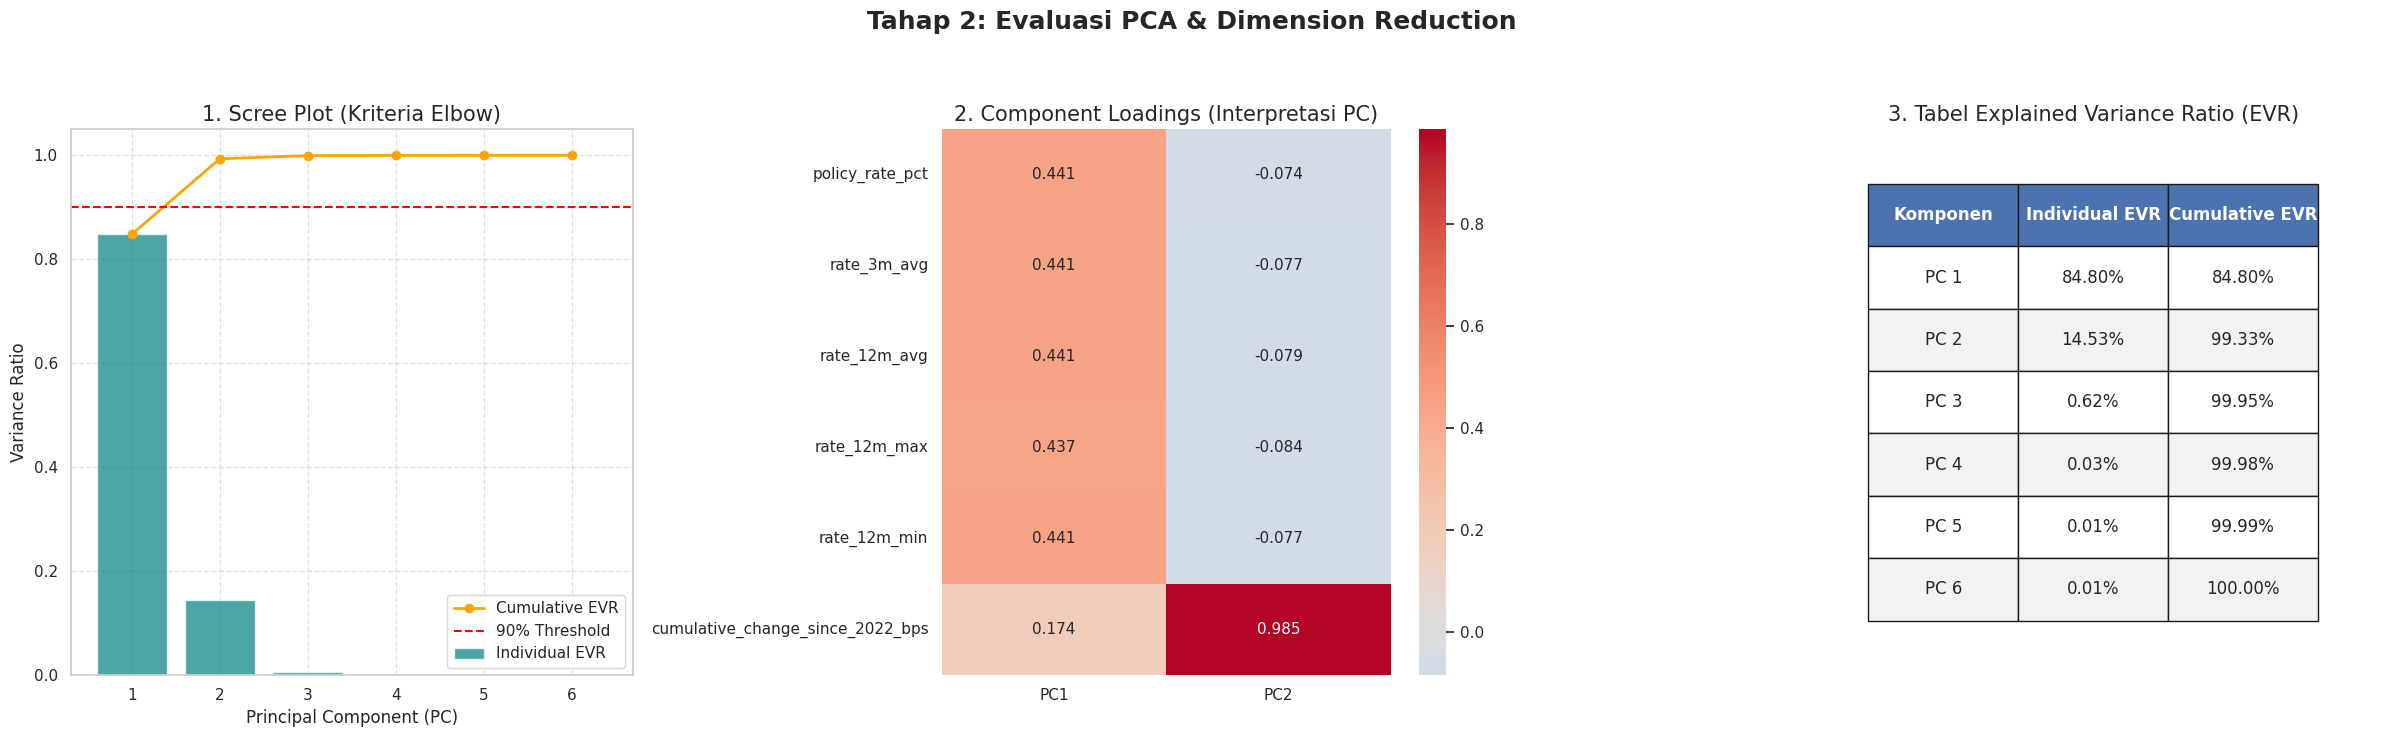

=== RINGKASAN DAMPAK PCA ===
1. Total Informasi yang Dipertahankan (PC1 + PC2) : 99.33%
2. Korelasi Baru antara PC1 dan PC2 (Bukti Ortogonal): 0.000


In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA

# ==========================================
# 1. PIPELINE TRANSFORMASI (Targeted Yeo-Johnson & Z-Score)
# ==========================================
X_prepared = df_clean[fitur_makro].copy()

# A. Pisahkan fitur yang butuh Normalisasi Distribusi
fitur_skew = ['policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min']

# Aplikasikan Yeo-Johnson Transformation (Sesuai Pipeline.pdf Hal 3)
pt = PowerTransformer(method='yeo-johnson')
X_prepared[fitur_skew] = pt.fit_transform(X_prepared[fitur_skew])

# B. Z-Score Standardization (Aplikasikan ke SEMUA fitur agar skala seimbang)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared)

# Ubah kembali ke dataframe
df_scaled = pd.DataFrame(X_scaled, columns=fitur_makro, index=df_clean.index)

# ==========================================
# 2. MODEL PCA (DIMENSION REDUCTION) & EVALUASI EVR
# ==========================================
# Fit PCA untuk semua komponen
pca_full = PCA()
pca_full.fit(df_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# ==========================================
# 3. VISUALISASI DALAM 1 KANVAS (1 Print)
# ==========================================
# Membuat kanvas panjang dengan 3 subplot (1 Baris, 3 Kolom)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Tahap 2: Evaluasi PCA & Dimension Reduction', fontsize=18, fontweight='bold', y=1.05)

# --- CHART 1: SCREE PLOT ---
axes[0].bar(range(1, len(evr)+1), evr, alpha=0.7, color='teal', label='Individual EVR')
axes[0].plot(range(1, len(evr)+1), cum_evr, marker='o', linestyle='-', color='orange', linewidth=2, label='Cumulative EVR')
axes[0].axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')
axes[0].set_title('1. Scree Plot (Kriteria Elbow)', fontsize=15)
axes[0].set_xlabel('Principal Component (PC)', fontsize=12)
axes[0].set_ylabel('Variance Ratio', fontsize=12)
axes[0].set_xticks(range(1, len(evr)+1))
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- CHART 2: COMPONENT LOADINGS ---
# Eksekusi PCA Final (Ambil 2 Komponen Utama saja)
pca_final = PCA(n_components=2)
X_pca = pca_final.fit_transform(df_scaled)

# Simpan hasil PC ke dalam dataset kita
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=['PC1', 'PC2'],
    index=fitur_makro
)
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".3f", center=0, ax=axes[1], annot_kws={"size": 11})
axes[1].set_title('2. Component Loadings (Interpretasi PC)', fontsize=15)

# --- CHART 3: TABEL EVR ---
axes[2].axis('off') # Matikan grid/garis sumbu karena kita mau gambar tabel
axes[2].set_title('3. Tabel Explained Variance Ratio (EVR)', fontsize=15)

# Siapkan data untuk tabel
evr_df = pd.DataFrame({
    'Komponen': [f'PC {i}' for i in range(1, len(evr)+1)],
    'Individual EVR': [f"{x:.2%}" for x in evr],
    'Cumulative EVR': [f"{x:.2%}" for x in cum_evr]
})

# Gambar tabel di Matplotlib
table = axes[2].table(
    cellText=evr_df.values,
    colLabels=evr_df.columns,
    loc='center',
    cellLoc='center',
    bbox=[0.1, 0.1, 0.8, 0.8] # [x, y, width, height]
)

# Percantik tabel
table.auto_set_font_size(False)
table.set_fontsize(12)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4c72b0') # Header biru
    else:
        cell.set_facecolor('#f2f2f2' if row % 2 == 0 else 'white') # Baris belang-belang

plt.tight_layout()
plt.show()

# Print Kesimpulan Numerik
print("=== RINGKASAN DAMPAK PCA ===")
print(f"1. Total Informasi yang Dipertahankan (PC1 + PC2) : {cum_evr[1]:.2%}")
print(f"2. Korelasi Baru antara PC1 dan PC2 (Bukti Ortogonal): {np.corrcoef(df_clean['PC1'], df_clean['PC2'])[0, 1]:.3f}")

## 3. Chart "Sesudah" Transformasi & Dimension Reduction

--- TABEL STATISTIK PASCA TRANSFORMASI (YEO-JOHNSON + Z-SCORE) ---


,policy_rate_pct,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,cumulative_change_since_2022_bps
count,36.000,36.000,36.000,36.000,36.000,36.000
mean,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.014,1.014,1.014,1.014,1.014,1.014
min,-2.688,-2.530,-2.293,-2.099,-2.697,-3.076
25%,-0.394,-0.402,-0.534,-0.534,-0.387,-0.337
50%,-0.101,-0.081,0.032,-0.004,-0.093,-0.142
75%,0.592,0.636,0.576,0.494,0.603,0.180
max,2.211,2.183,2.162,2.117,2.227,4.526
skewness,-0.020,0.011,0.044,0.091,-0.025,1.848
kurtosis,0.784,0.465,0.174,-0.035,0.822,13.138


/tmp/ipykernel_7328/2912271374.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




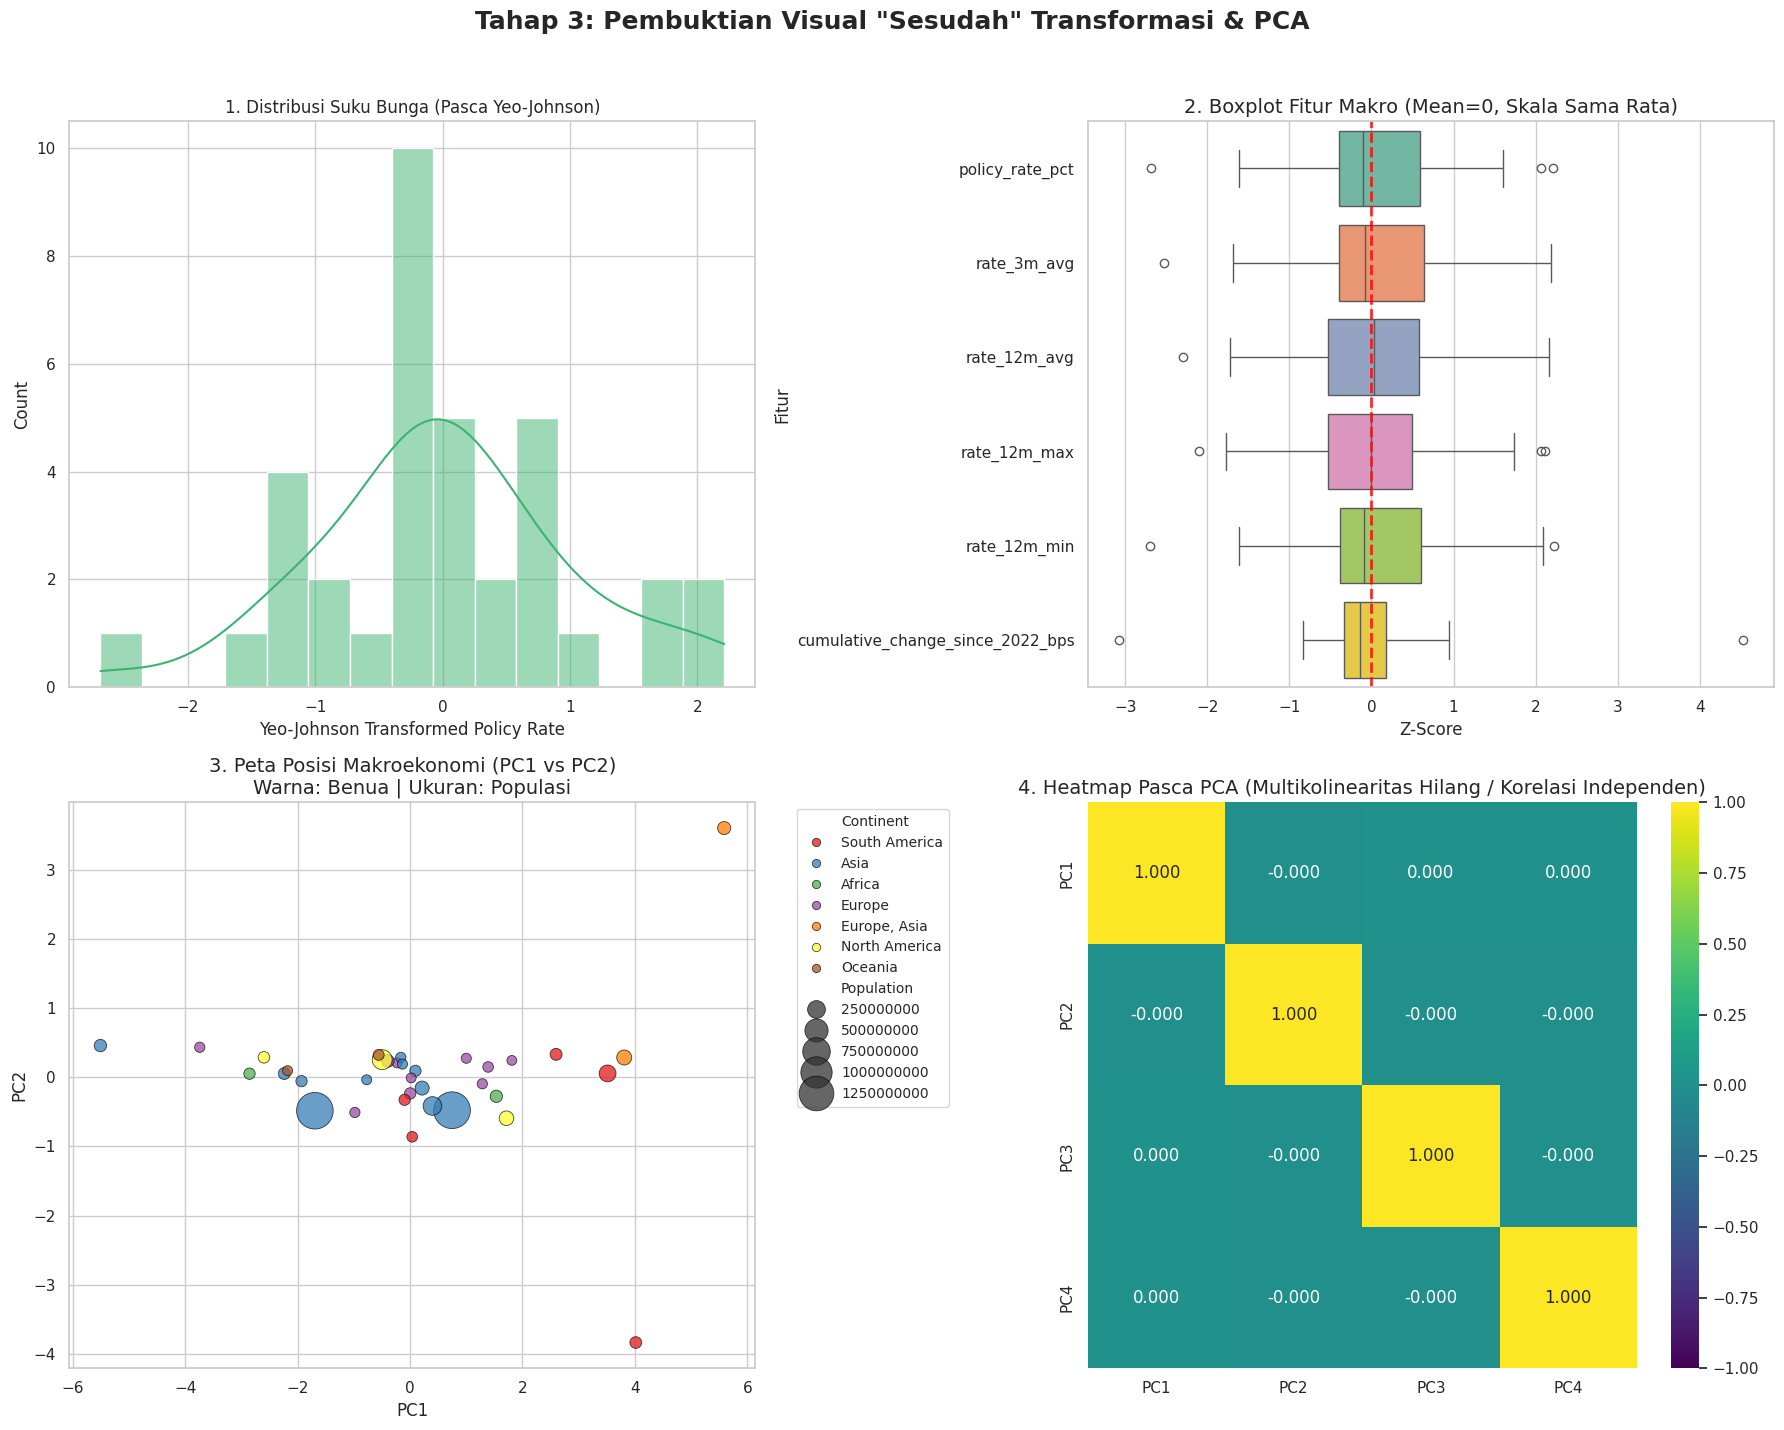

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# A. TABEL STATISTIK PASCA-TRANSFORMASI (LENGKAP)
# ==========================================
print("--- TABEL STATISTIK PASCA TRANSFORMASI (YEO-JOHNSON + Z-SCORE) ---")

# 1. Menghitung describe dasar
stats_scaled = df_scaled.describe().round(3)

# 2. Menambahkan Skewness & Kurtosis secara eksplisit
stats_scaled.loc['skewness'] = df_scaled.skew().round(3)
stats_scaled.loc['kurtosis'] = df_scaled.kurtosis().round(3)

# 3. Menampilkan tabel
display(stats_scaled)

# ==========================================
# B. PERSIAPAN DATA VISUALISASI
# ==========================================
# Menyiapkan DataFrame gabungan untuk Scatter Plot PCA
df_pca_viz = pd.DataFrame({
    'PC1': df_clean['PC1'].values,
    'PC2': df_clean['PC2'].values,
    'Continent': df_clean['continent'].values,
    'Population': df_clean['population'].values,
    'Log_policy_rate': np.log1p(df_clean['policy_rate_pct']).values
})

# ==========================================
# C. VISUALISASI 4 CHART
# ==========================================
# Mengatur grid 2x2 untuk 4 Chart
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Tahap 3: Pembuktian Visual "Sesudah" Transformasi & PCA', fontsize=18, fontweight='bold', y=1.02)

# --- CHART 1: HISTOGRAM YEO-JOHNSON ---
# Pastikan nama kolom disesuaikan dengan dataframe yang Anda pakai,
# misal jika Anda memanggil dari data yang sudah ditransformasi (X_scaled/df_scaled)
sns.histplot(df_scaled['policy_rate_pct'], bins=15, kde=True, color='mediumseagreen', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribusi Suku Bunga (Pasca Yeo-Johnson)')
axes[0, 0].set_xlabel('Yeo-Johnson Transformed Policy Rate')

# Chart 2: Boxplot Pasca Normalisasi
df_scaled_melted = df_scaled.melt(var_name='Fitur', value_name='Z-Score')
sns.boxplot(x='Z-Score', y='Fitur', data=df_scaled_melted, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('2. Boxplot Fitur Makro (Mean=0, Skala Sama Rata)', fontsize=14)
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2)

# Chart 3: Scatter 2D Dimensi Baru (Warna: Benua, Ukuran: Populasi)
scatter = sns.scatterplot(
    x='PC1', y='PC2', hue='Continent', size='Population', sizes=(50, 700),
    data=df_pca_viz, palette='Set1', ax=axes[1, 0], alpha=0.75, edgecolor='black'
)
axes[1, 0].set_title('3. Peta Posisi Makroekonomi (PC1 vs PC2)\nWarna: Benua | Ukuran: Populasi', fontsize=14)
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Chart 4: Heatmap Baru
X_pca_4 = pca_full.transform(df_scaled)[:, :4]
df_pca_components = pd.DataFrame(X_pca_4, columns=['PC1', 'PC2', 'PC3', 'PC4'])
sns.heatmap(df_pca_components.corr(), annot=True, cmap='viridis', fmt=".3f", ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('4. Heatmap Pasca PCA (Multikolinearitas Hilang / Korelasi Independen)', fontsize=14)

plt.tight_layout()
plt.show()

## Tahap 4: Analisis Geospasial / Map

Karena dataset utama kami tidak memiliki titik koordinat (Latitude-Longitude), kita perlu melakukan pengayaan data (*Data Enrichment*) menggunakan data *lookup* poligon wilayah.

**Proses Pengayaan (Join):**
1. **Sumber Data:** Kami import file GeoJSON publik yang memuat batas poligon seluruh negara di dunia.
2. **Proses Join:** Kami melakukan *Left Join* antara data moneter kita dengan peta GeoJSON menggunakan *Key* berupa nama negara. Spesifiknya, kolom `country_name` di data kita dicocokkan dengan atribut `feature.properties.name` pada GeoJSON.
3. **Pembersihan Key:** Untuk mencegah kegagalan *join* akibat perbedaan kapitalisasi huruf (misal: "Indonesia" vs "INDONESIA"), kami melakukan penyesuaian (*preprocessing*) dengan mengubah kedua *key* menjadi **Huruf Besar (Uppercase)** sebelum peta dirender.

In [ ]:
import plotly.express as px

# ==========================================
# TAHAP 4: DATA ENRICHMENT & CHOROPLETH MAP
# ==========================================
# Konsep: Plotly akan melakukan "Key Matching" (Left Join) antara
# kolom 'country_name' pada data kita dengan database GeoJSON miliknya.

fig = px.choropleth(
    df_clean,
    locations="country_name",         # PRIMARY KEY dari tabel kita (Tabel Kiri)
    locationmode="country names",     # Mencocokkan dengan KEY di database spasial Plotly (Tabel Kanan)
    color="policy_rate_pct",          # Metrik agregasi yang menentukan warna wilayah
    hover_name="country_name",
    hover_data={
        "continent": True,
        "policy_rate_pct": True,
        "cumulative_change_since_2022_bps": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    color_continuous_scale=px.colors.sequential.Reds, # Skala warna (Merah = Krisis/Restriktif)
    title="Peta Distribusi Rezim Makroekonomi Pasca-Pandemi (Tingkat Suku Bunga)",
    projection="natural earth"        # Menggunakan proyeksi melengkung (lebih akurat secara spasial)
)

# Mempercantik tampilan peta (Layouting)
fig.update_layout(
    geo=dict(
        showframe=False,       # Menghilangkan bingkai kotak
        showcoastlines=True,   # Menegaskan garis pantai
        coastlinecolor="Black",
        showland=True,
        landcolor="lightgrey"  # Warna untuk negara yang nilainya NaN (tidak masuk df_clean)
    ),
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(
        title="Policy Rate (%)",
        thicknessmode="pixels", thickness=20,
        lenmode="pixels", len=300,
        yanchor="top", y=0.8
    )
)

# Tampilkan Peta Interaktif
fig.show()

### ASSET PPT

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# PENGATURAN STANDAR UKURAN PPT (16:9 ratio)
# ==========================================
STD_FIGSIZE = (10, 6)
DPI_RES = 300
sns.set_theme(style="whitegrid")

print("Memulai proses ekspor 11 gambar untuk presentasi (Update Yeo-Johnson)...")

# =====================================================================
# TAHAP 1: EKSPLORASI & ANOMALI DATA (4 GAMBAR)
# =====================================================================
# 1. Histogram Tahap 1
plt.figure(figsize=STD_FIGSIZE)
sns.histplot(df_clean['policy_rate_pct'], kde=True, color='royalblue')
plt.title('1. Distribusi Suku Bunga Utama (Right-Skewed)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Policy Rate (%)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.tight_layout()
plt.savefig('Tahap1_1_Histogram.png', dpi=DPI_RES)
plt.close()

# 2. Boxplot Tahap 1
plt.figure(figsize=STD_FIGSIZE)
sns.boxplot(x=df_clean['policy_rate_pct'], color='salmon')
plt.title('2. Deteksi Hiperinflasi / Outlier Ekstrem', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Policy Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('Tahap1_2_Boxplot.png', dpi=DPI_RES)
plt.close()

# 3. Heatmap Korelasi Tahap 1
plt.figure(figsize=STD_FIGSIZE)
corr_matrix = df_clean[fitur_makro].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, annot_kws={"size": 12})
plt.title('3. Heatmap Korelasi (Ancaman Multikolinearitas > 0.69)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('Tahap1_3_Heatmap.png', dpi=DPI_RES)
plt.close()

# 4. Regplot Redundansi Tahap 1
plt.figure(figsize=STD_FIGSIZE)
sns.regplot(x='policy_rate_pct', y='rate_12m_avg', data=df_clean,
            scatter_kws={'color': 'purple', 'alpha': 0.7, 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('4. Bukti Redundansi Linier: Policy Rate vs 12M Avg', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Policy Rate (%)', fontsize=12)
plt.ylabel('12 Month Avg Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('Tahap1_4_Regplot.png', dpi=DPI_RES)
plt.close()

# =====================================================================
# TAHAP 2: EVALUASI PCA (3 GAMBAR)
# =====================================================================
# 1. Scree Plot Tahap 2
plt.figure(figsize=STD_FIGSIZE)
plt.bar(range(1, len(evr)+1), evr, alpha=0.7, color='teal', label='Individual EVR')
plt.plot(range(1, len(evr)+1), cum_evr, marker='o', linestyle='-', color='orange', linewidth=2, label='Cumulative EVR')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')
plt.title('1. Scree Plot (Kriteria Ekstraksi Variance)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Principal Component (PC)', fontsize=12)
plt.ylabel('Variance Ratio', fontsize=12)
plt.xticks(range(1, len(evr)+1))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('Tahap2_1_ScreePlot.png', dpi=DPI_RES)
plt.close()

# 2. Component Loadings Tahap 2
plt.figure(figsize=STD_FIGSIZE)
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".3f", center=0, annot_kws={"size": 14})
plt.title('2. Component Loadings (Interpretasi PC)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('Tahap2_2_Loadings.png', dpi=DPI_RES)
plt.close()

# 3. Tabel EVR Tahap 2
plt.figure(figsize=STD_FIGSIZE)
plt.axis('off')
plt.title('3. Tabel Explained Variance Ratio (EVR)', fontsize=16, fontweight='bold', pad=15)
# Membuat dataframe EVR untuk tabel
evr_df = pd.DataFrame({
    'Komponen': [f'PC {i}' for i in range(1, len(evr)+1)],
    'Individual EVR': [f"{x:.2%}" for x in evr],
    'Cumulative EVR': [f"{x:.2%}" for x in cum_evr]
})
table = plt.table(cellText=evr_df.values, colLabels=evr_df.columns, loc='center', cellLoc='center', bbox=[0.1, 0.2, 0.8, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(14)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4c72b0')
    else:
        cell.set_facecolor('#f2f2f2' if row % 2 == 0 else 'white')
plt.tight_layout()
plt.savefig('Tahap2_3_TabelEVR.png', dpi=DPI_RES)
plt.close()

# =====================================================================
# TAHAP 3: VALIDASI PASCA TRANSFORMASI (4 GAMBAR)
# =====================================================================
# 1. Histogram Yeo-Johnson Tahap 3 (REVISI LABEL)
plt.figure(figsize=STD_FIGSIZE)
sns.histplot(df_scaled['policy_rate_pct'], bins=15, kde=True, color='mediumseagreen')
plt.title('1. Distribusi Suku Bunga (Pasca Yeo-Johnson)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Yeo-Johnson Transformed Policy Rate', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.tight_layout()
plt.savefig('Tahap3_1_HistogramYeoJohnson.png', dpi=DPI_RES)
plt.close()

# 2. Boxplot Z-Score Tahap 3
plt.figure(figsize=STD_FIGSIZE)
# Membuat dataframe leleh (melted) khusus untuk boxplot Z-Score
df_scaled_melted = df_scaled.melt(var_name='Fitur', value_name='Z-Score')
sns.boxplot(x='Z-Score', y='Fitur', data=df_scaled_melted, palette='Set2', hue='Fitur', legend=False)
plt.title('2. Boxplot Fitur Makro (Mean=0, Skala Sama Rata)', fontsize=16, fontweight='bold', pad=15)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
plt.tight_layout()
plt.savefig('Tahap3_2_BoxplotZscore.png', dpi=DPI_RES)
plt.close()

# 3. Scatter Plot PCA Tahap 3
plt.figure(figsize=STD_FIGSIZE)
sns.scatterplot(x='PC1', y='PC2', hue='Continent', size='Population', sizes=(100, 1000),
                data=df_pca_viz, palette='Set1', alpha=0.8, edgecolor='black')
plt.title('3. Peta Posisi Makroekonomi (PC1 vs PC2)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('PC1 (Level Suku Bunga)', fontsize=12)
plt.ylabel('PC2 (Agresivitas Moneter)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('Tahap3_3_ScatterPCA.png', dpi=DPI_RES)
plt.close()

# 4. Heatmap PCA Tahap 3
plt.figure(figsize=STD_FIGSIZE)
sns.heatmap(df_pca_components.corr(), annot=True, cmap='viridis', fmt=".3f", vmin=-1, vmax=1, annot_kws={"size": 14})
plt.title('4. Heatmap Pasca PCA (Orthogonal / Independen)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('Tahap3_4_HeatmapPCA.png', dpi=DPI_RES)
plt.close()

print("Selesai! 11 Gambar PNG beresolusi tinggi telah berhasil disimpan dan siap di-drag ke PowerPoint.")

Memulai proses ekspor 11 gambar untuk presentasi (Update Yeo-Johnson)...
Selesai! 11 Gambar PNG beresolusi tinggi telah berhasil disimpan dan siap di-drag ke PowerPoint.
